# Model Comparison with Fixed Sample Size

## Setup

In [ ]:

library(here)


here() starts at C:/Users/pablo/OneDrive/Github/cfa-power

This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.

###############################################################################

This is semTools 0.5-8

All users of R (or SEM) are invited to submit functions or ideas for functions.

...


Attaching package: 'dplyr'

The following object is masked from 'package:MASS':

    select

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Loading required package: SparseM

## Model comparison: Power to detect H1 vs H0

Make table with resume.

## Power Analysis with fixed N

Ideial condition: PA it not too sensitive to distributional assumptions, missing data, etc. So, we use ideal for time consuming simulations. We can also do the same for the robust conditions, but it will take more time.

In [ ]:

popmodel_fixed <- cache_or_run("popmodel_fixed", {
    sim(
        REP,
        n = 350,
        pmMCAR = 0.10,
        analyzemodel,
        generate = popmodel,
        indDist = dist,       # See the `dist` object defined in helpers.R for the range of skewness and kurtosis values.
        std.lv = TRUE,
        lavaanfun = "cfa",
        estimator = "mlr",
        missing = "fiml",
        seed = SEED,
        multicore = TRUE
    )
})


In [ ]:

h1model_fixed <- cache_or_run("h1model_fixed", {
    sim(
        REP,
        n = 350,
        pmMCAR = 0.10,
        analyzemodel,
        generate = h1model,
        indDist = dist,      # See the `dist` object defined in helpers.R for the range of skewness and kurtosis values.
        std.lv = TRUE,
        lavaanfun = "cfa",
        estimator = "mlr",
        missing = "fiml",
        seed = SEED,
        multicore = TRUE
    )
})


### Power curves for fit indices

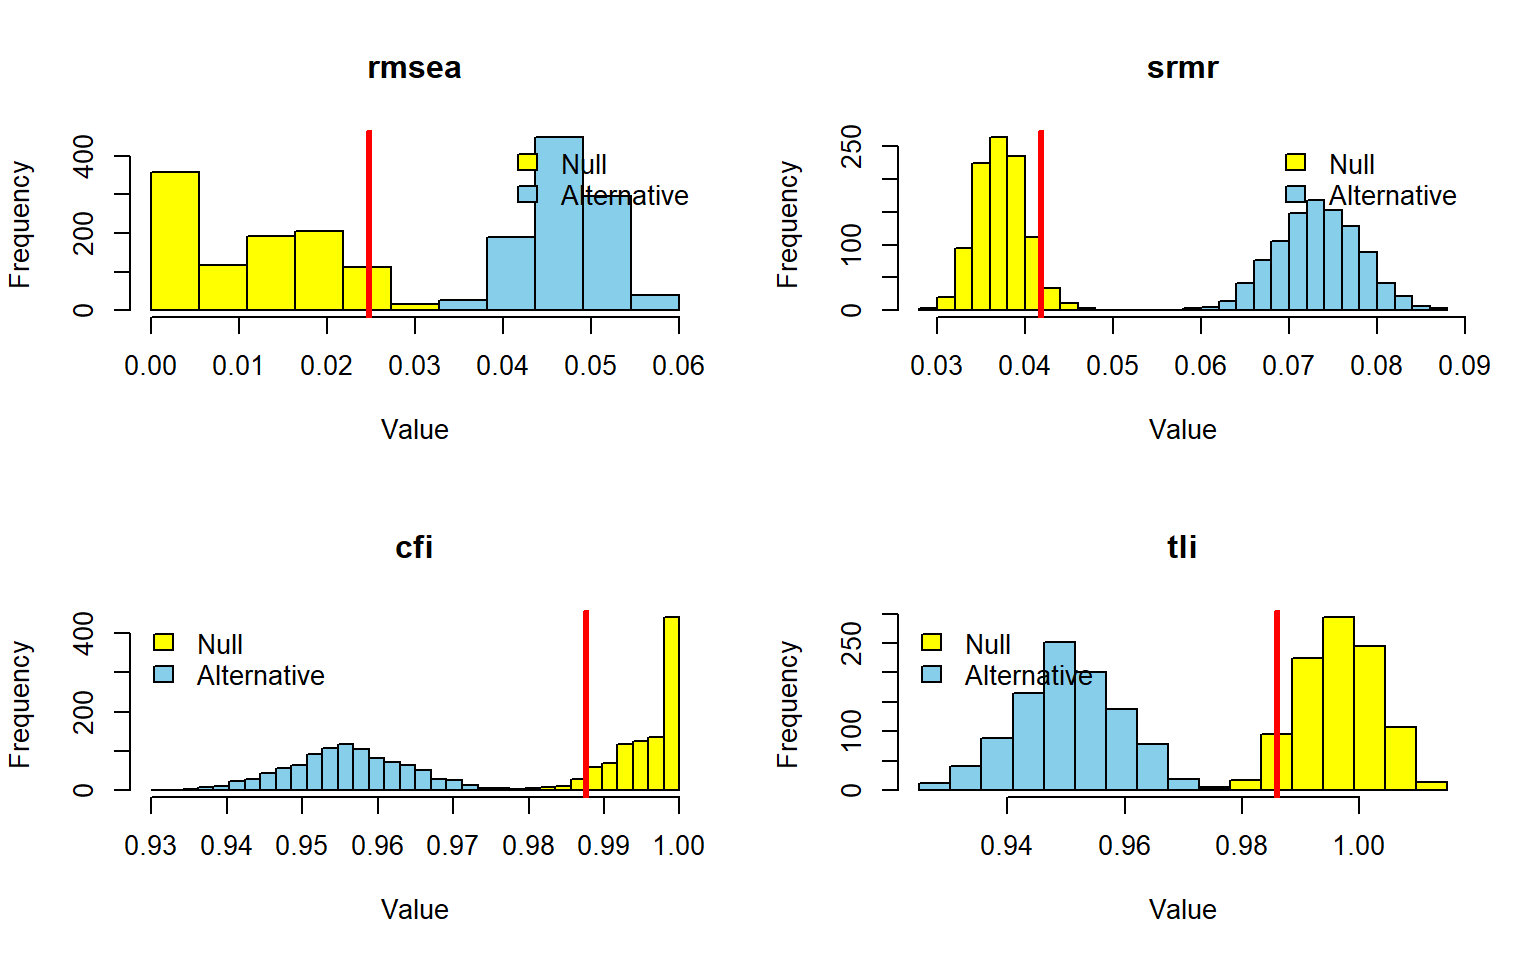

In [ ]:

plotPowerFit(
    h1model_fixed,
    popmodel_fixed,
    alpha = ALPHA,
    usedFit = FITS
)


### Power cutoff values for fit indices

You extract the cutoff values for fit indices at a given alpha level and sample size to determine the threshold for acceptable fit under the null model. This allows you to see how stringent the fit criteria are at different sample sizes.

``` r

getPowerFit(
    h1model_fixed,
    nullObject = popmodel_fixed,
    alpha = ALPHA,
    usedFit = FITS
)
```

    TraditionalChi          rmsea           srmr            cfi            tli 
                 1              1              1              1              1 

``` r

getCutoff(
    popmodel_fixed,
    alpha = ALPHA,
    usedFit = FITS
)
```

             rmsea       srmr       cfi       tli
    95% 0.02473118 0.04184716 0.9875703 0.9859975

``` r

summaryParam(h1model_fixed, alpha = ALPHA, digits = 3, detail = TRUE)
```

                          Estimate Average Estimate SD Average SE
    psycho=~Q5                       0.917       0.050      0.049
    psycho=~Q6                       0.808       0.053      0.053
    psycho=~Q7                       0.936       0.050      0.049
    psycho=~Q11                      0.726       0.055      0.055
    psycho=~Q19                      0.747       0.056      0.054
    psycho=~Q26                      0.631       0.060      0.057
    physical=~Q3                     0.836       0.054      0.054
    physical=~Q4                     0.828       0.056      0.054
    physical=~Q10                    0.630       0.057      0.057
    physical=~Q15                    0.761       0.055      0.056
    physical=~Q16                    0.678       0.059      0.057
    physical=~Q17                    0.888       0.055      0.054
    physical=~Q18                    0.608       0.057      0.058
    social=~Q20                      0.939       0.055      0.055
    social=~Q21                      0.888       0.055      0.055
    social=~Q22                      0.780       0.059      0.057
    environment=~Q8                  0.506       0.057      0.060
    environment=~Q9                  0.550       0.058      0.058
    environment=~Q12                 0.782       0.057      0.057
    environment=~Q13                 0.805       0.057      0.057
    environment=~Q14                 0.765       0.059      0.058
    environment=~Q23                 0.745       0.059      0.058
    environment=~Q24                 0.635       0.060      0.059
    environment=~Q25                 0.728       0.062      0.058
    psycho~~physical                 0.208       0.055      0.055
    psycho~~social                   0.205       0.057      0.055
    psycho~~environment              0.258       0.057      0.058
    physical~~social                 0.208       0.056      0.056
    physical~~environment            0.248       0.058      0.058
    social~~environment              0.214       0.058      0.057
    Q3~~Q4                           0.094       0.028      0.028
    Q5~~Q5                           0.153       0.022      0.022
    Q6~~Q6                           0.342       0.038      0.037
    Q7~~Q7                           0.115       0.020      0.020
    Q11~~Q11                         0.465       0.048      0.047
    Q19~~Q19                         0.434       0.045      0.044
    Q26~~Q26                         0.599       0.060      0.059
    Q3~~Q3                           0.295       0.034      0.036
    Q4~~Q4                           0.313       0.038      0.037
    Q10~~Q10                         0.598       0.061      0.061
    Q15~~Q15                         0.413       0.046      0.044
    Q16~~Q16                         0.534       0.056      0.055
    Q17~~Q17                         0.210       0.031      0.030
    Q18~~Q18                         0.623       0.065      0.064
    Q20~~Q20                         0.115       0.033      0.032
    Q21~~Q21                         0.205       0.034      0.033
    Q22~~Q22                         0.390       0.044      0.044
    Q8~~Q8                           0.733       0.073      0.074
    Q9~~Q9                           0.692       0.073      0.069
    Q12~~Q12                         0.378       0.046      0.044
    Q13~~Q13                         0.348       0.044      0.042
    Q14~~Q14                         0.409       0.052      0.048
    Q23~~Q23                         0.438       0.051      0.051
    Q24~~Q24                         0.587       0.067      0.065
    Q25~~Q25                         0.466       0.059      0.055
    Q5~1                             0.001       0.055      0.054
    Q6~1                            -0.001       0.055      0.054
    Q7~1                             0.000       0.054      0.054
    Q11~1                            0.000       0.054      0.055
    Q19~1                           -0.001       0.054      0.055
    Q26~1                            0.000       0.058      0.055
    Q3~1                             0.000       0.055      0.054
    Q4~1                             0.001       0.055      0.054
    Q10~1                            0.000       0.054      0.055
    Q15~1                            0.002       0.055      0.055
    Q16~1                           -0.001       0.055      0.055
    Q17~1                            0.001       0.053      0.054
    Q18~1                            0.000       0.055      0.055
    Q20~1                            0.000       0.056      0.054
    Q21~1                            0.001       0.056      0.054
    Q22~1                           -0.001       0.055      0.055
    Q8~1                             0.001       0.056      0.055
    Q9~1                             0.001       0.055      0.055
    Q12~1                            0.000       0.054      0.055
    Q13~1                            0.001       0.053      0.055
    Q14~1                            0.001       0.052      0.055
    Q23~1                           -0.001       0.054      0.055
    Q24~1                           -0.001       0.056      0.055
    Q25~1                           -0.001       0.056      0.055
                          Power (Not equal 0) Std Est Std Est SD Std Ave SE
    psycho=~Q5                          1.000   0.919      0.013      0.013
    psycho=~Q6                          1.000   0.810      0.023      0.023
    psycho=~Q7                          1.000   0.940      0.011      0.011
    psycho=~Q11                         1.000   0.728      0.031      0.030
    psycho=~Q19                         1.000   0.749      0.029      0.028
    psycho=~Q26                         1.000   0.631      0.038      0.037
    physical=~Q3                        1.000   0.838      0.021      0.022
    physical=~Q4                        1.000   0.828      0.023      0.022
    physical=~Q10                       1.000   0.630      0.037      0.037
    physical=~Q15                       1.000   0.763      0.027      0.028
    physical=~Q16                       1.000   0.679      0.034      0.034
    physical=~Q17                       1.000   0.888      0.018      0.017
    physical=~Q18                       1.000   0.609      0.039      0.038
    social=~Q20                         1.000   0.940      0.018      0.017
    social=~Q21                         1.000   0.890      0.020      0.019
    social=~Q22                         1.000   0.780      0.026      0.026
    environment=~Q8                     1.000   0.508      0.045      0.047
    environment=~Q9                     1.000   0.550      0.043      0.043
    environment=~Q12                    1.000   0.785      0.027      0.027
    environment=~Q13                    1.000   0.806      0.025      0.025
    environment=~Q14                    1.000   0.766      0.029      0.029
    environment=~Q23                    1.000   0.747      0.030      0.030
    environment=~Q24                    1.000   0.637      0.039      0.038
    environment=~Q25                    1.000   0.728      0.033      0.032
    psycho~~physical                    0.956   0.208      0.055      0.055
    psycho~~social                      0.946   0.205      0.057      0.055
    psycho~~environment                 0.991   0.258      0.057      0.058
    physical~~social                    0.953   0.208      0.056      0.056
    physical~~environment               0.987   0.248      0.058      0.058
    social~~environment                 0.940   0.214      0.058      0.057
    Q3~~Q4                              0.937   0.305      0.073      0.073
    Q5~~Q5                              1.000   0.154      0.024      0.023
    Q6~~Q6                              1.000   0.344      0.037      0.037
    Q7~~Q7                              1.000   0.116      0.022      0.021
    Q11~~Q11                            1.000   0.469      0.044      0.043
    Q19~~Q19                            1.000   0.438      0.043      0.042
    Q26~~Q26                            1.000   0.601      0.048      0.046
    Q3~~Q3                              1.000   0.298      0.035      0.036
    Q4~~Q4                              1.000   0.314      0.038      0.037
    Q10~~Q10                            1.000   0.601      0.046      0.047
    Q15~~Q15                            1.000   0.417      0.041      0.042
    Q16~~Q16                            1.000   0.538      0.047      0.045
    Q17~~Q17                            1.000   0.211      0.032      0.031
    Q18~~Q18                            1.000   0.627      0.047      0.047
    Q20~~Q20                            0.949   0.116      0.034      0.032
    Q21~~Q21                            0.999   0.207      0.036      0.034
    Q22~~Q22                            1.000   0.391      0.041      0.041
    Q8~~Q8                              1.000   0.740      0.045      0.048
    Q9~~Q9                              1.000   0.695      0.047      0.047
    Q12~~Q12                            1.000   0.383      0.042      0.042
    Q13~~Q13                            1.000   0.350      0.040      0.041
    Q14~~Q14                            1.000   0.412      0.045      0.044
    Q23~~Q23                            1.000   0.442      0.045      0.045
    Q24~~Q24                            1.000   0.592      0.050      0.049
    Q25~~Q25                            1.000   0.468      0.048      0.046
    Q5~1                                0.050   0.002      0.056      0.054
    Q6~1                                0.061   0.000      0.055      0.055
    Q7~1                                0.054   0.001      0.054      0.054
    Q11~1                               0.054   0.001      0.055      0.055
    Q19~1                               0.051   0.000      0.055      0.055
    Q26~1                               0.065   0.001      0.058      0.055
    Q3~1                                0.054   0.001      0.055      0.054
    Q4~1                                0.050   0.002      0.055      0.054
    Q10~1                               0.045   0.000      0.054      0.055
    Q15~1                               0.055   0.002      0.055      0.055
    Q16~1                               0.044  -0.001      0.055      0.055
    Q17~1                               0.040   0.000      0.053      0.054
    Q18~1                               0.057   0.000      0.056      0.055
    Q20~1                               0.060  -0.001      0.057      0.054
    Q21~1                               0.063   0.000      0.057      0.054
    Q22~1                               0.053  -0.002      0.056      0.055
    Q8~1                                0.050   0.002      0.057      0.056
    Q9~1                                0.043   0.001      0.055      0.056
    Q12~1                               0.045  -0.001      0.055      0.055
    Q13~1                               0.045   0.000      0.053      0.055
    Q14~1                               0.048   0.000      0.053      0.055
    Q23~1                               0.057  -0.002      0.055      0.055
    Q24~1                               0.051  -0.002      0.056      0.055
    Q25~1                               0.056  -0.002      0.056      0.055

## Power analysis with traditional fits

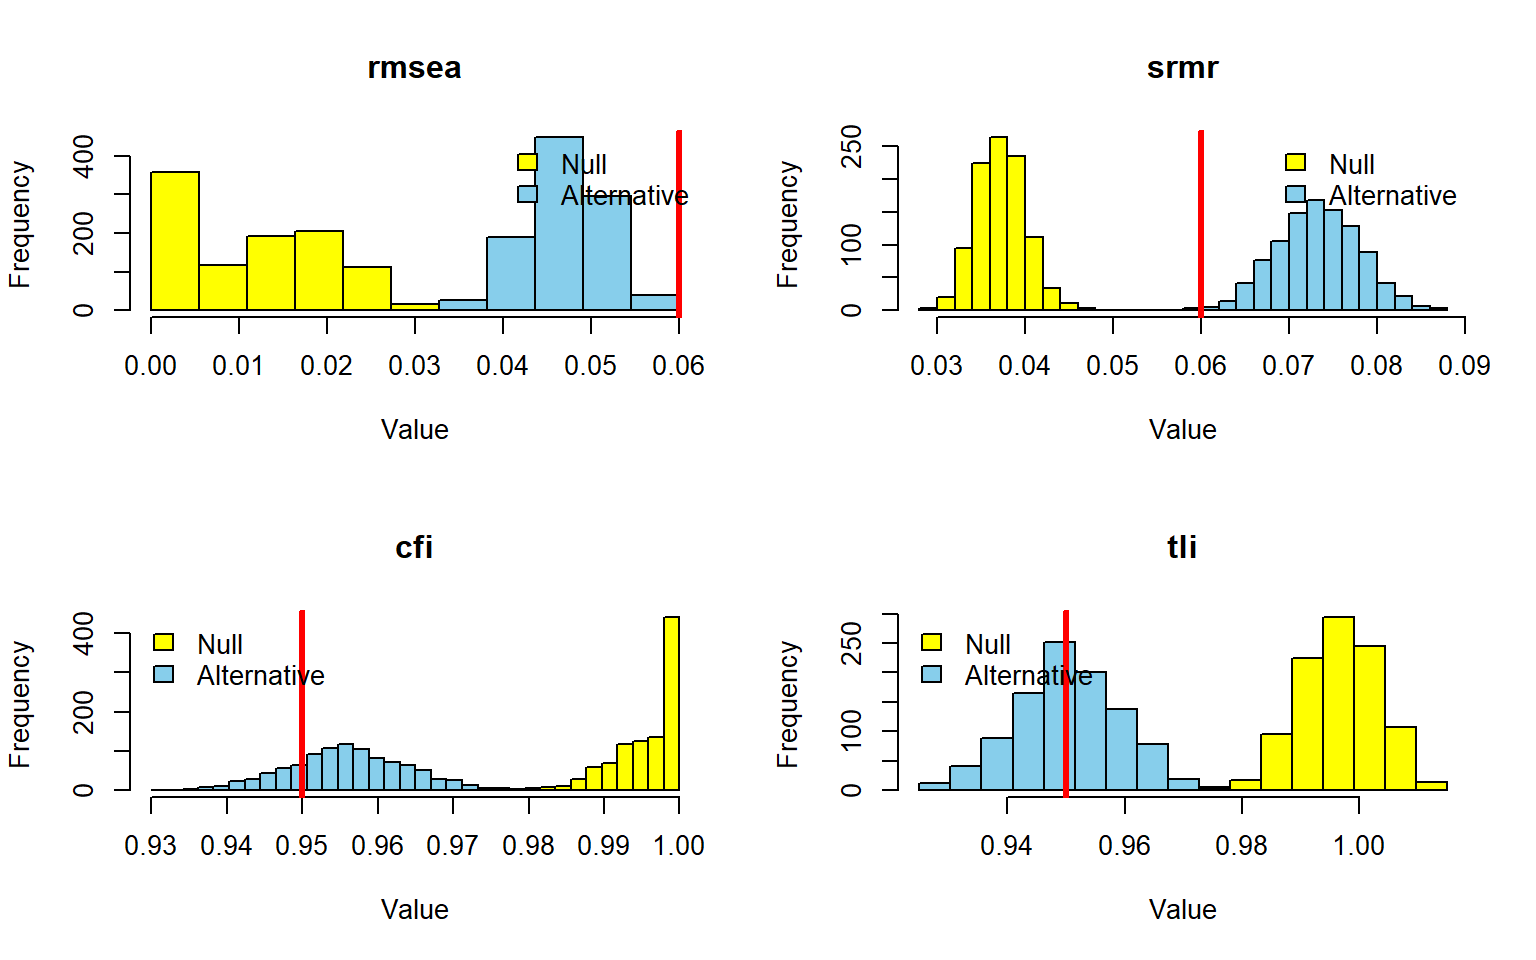

In [ ]:

plotPowerFit(
    h1model_fixed,
    popmodel_fixed,
    cutoff = RULE_OF_THUMB,
    alpha = ALPHA,
    usedFit = FITS
)


``` r

getPowerFit(
    h1model_fixed,
    RULE_OF_THUMB,
    alpha = ALPHA,
    usedFit = FITS
)
```

      cfi   tli rmsea  srmr 
    0.222 0.483 0.000 0.997